# HW3: Logistic Regression and Optimization

Welcome to the coding part of Homework 3. In this notebook, you will implement classification models from scratch using numpy. You will analyze the behavior of Gradient Descent, explore the effects of hyperparameters, and implement multiclass classification strategies (One-vs-Rest, One-vs-One, and Softmax).

# Due Date: Sunday, May 24, at 11:59 PM

This assignment is due on **Sunday, May 24, at 11:59 PM**. You must submit your work to LearnHub by this deadline.

**Dataset**: You will use the Wine Quality dataset (https://archive.ics.uci.edu/dataset/186/wine+quality) which contains physicochemical measurements of wines and a quality score assigned by human experts.

**Instructions**:

1. Do not use PyTorch, TensorFlow, or Scikit-Learn's LogisticRegression. You must implement the algorithms using numpy.
2. You may use sklearn only for data loading, splitting, and basic preprocessing (like scaling), but the core learning algorithms must be your own.
3. Fill in the code blocks marked with TODO.
4. Test your code thoroughly to ensure it meets the requirements.
5. Answer the conceptual questions with clear and concise written responses.

Good luck!

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

%matplotlib inline

# 1. Load and visualize the data

In [93]:
# Load Data
data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",
    sep=";"
)

X = data.drop("quality", axis=1).values
y_raw = data["quality"].values

print(f"Data shape: {X.shape}, Target shape: {y_raw.shape}")

Data shape: (4898, 11), Target shape: (4898,)


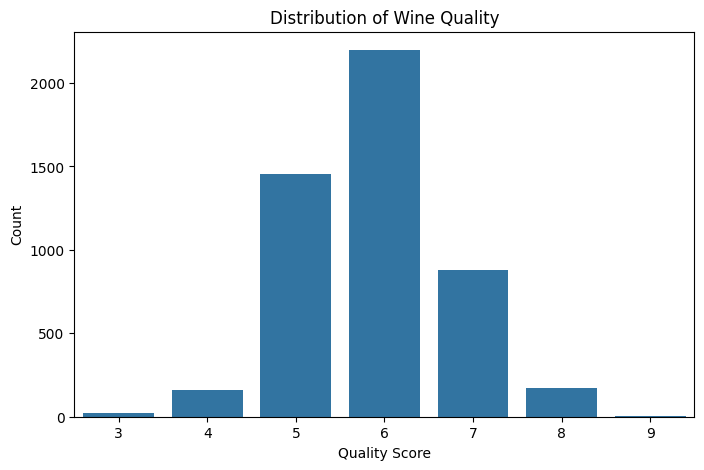

In [94]:
# Visualize the distribution of the target variable (quality)
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

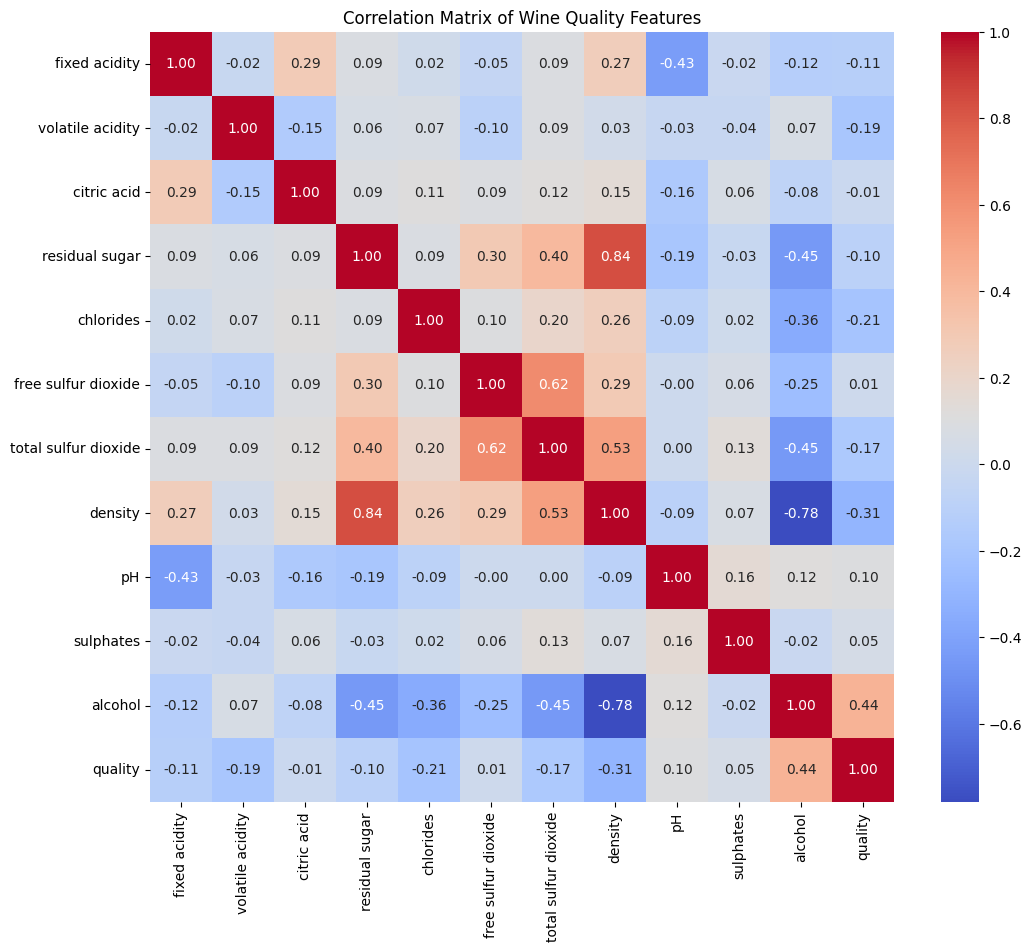

In [95]:
# Visualize the correlations between the features and the target variable
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Wine Quality Features')
plt.show()

**Q1**: Based on the visualizations, what observations can you make about the distribution of wine quality (the target variable) and the relationships between features? Are there any clear correlations visible?

**Answer**: Wine quality has the strongest correlation with alcohol as positive correlation. Also, it has negative correlation with density and chlorides. Even if they are the highest ones, none of them is greater than 0.5.

# 2. Binary Logistic Regression

 We will start by simplifying the problem to a Binary Classification task. We will train a model to distinguish High Quality (Quality > 6) from Low Quality (Quality <= 6).

First, we will set the labels of the datapoints to 1 if the original label is higher than 6, to 0 otherwise. Additionally, we will map the original labels to class indices starting from 0 for multiclass classification that you will implement in the next steps.



In [96]:
# Binary labels: 1 if quality > 6, else 0
y_binary = (y_raw > 6).astype(int)

# Map original labels to class indices starting from 0. (for multiclass classification, do not worry about it right now)
quality_to_class = {}
qualities = np.unique(y_raw)
classes = np.arange(len(qualities))
for q, c in zip(qualities, classes):
    quality_to_class[q] = c

y_multi = np.array([quality_to_class[q] for q in y_raw])

print("Class distribution (original):", np.bincount(y_multi))
print("Class distribution (binary):", np.bincount(y_binary))

Class distribution (original): [  20  163 1457 2198  880  175    5]
Class distribution (binary): [3838 1060]


Next, we split the data into train, validation and test sets. We also apply standardization.

In [97]:
# Split data (80% train, 10% validation, 10% test)
np.random.seed(42)

n_samples = X.shape[0]

indices = np.arange(n_samples)
np.random.shuffle(indices)

train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

train_size = int(train_ratio * n_samples)
val_size = int(val_ratio * n_samples)
test_size = n_samples - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size : train_size + val_size]
test_indices = indices[train_size + val_size :]

X_train, y_train, y_train_bin = X[train_indices], y_multi[train_indices], y_binary[train_indices]
X_val, y_val, y_val_bin = X[val_indices], y_multi[val_indices], y_binary[val_indices]
X_test, y_test, y_test_bin = X[test_indices], y_multi[test_indices], y_binary[test_indices]


# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Scale test set

We add the column of 1s to each split accounting for the bias term in the model.

In [98]:
# Add intercept term (bias)
# We append a column of ones to X so we can use dot product w^T x
def add_intercept(X):
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

X_train_aug = add_intercept(X_train_scaled)
X_val_aug = add_intercept(X_val_scaled)
X_test_aug = add_intercept(X_test_scaled) # Add intercept to test set

print("Shape after adding intercept (Train):", X_train_aug.shape)
print("Shape after adding intercept (Validation):", X_val_aug.shape)
print("Shape after adding intercept (Test):", X_test_aug.shape)

Shape after adding intercept (Train): (3918, 12)
Shape after adding intercept (Validation): (489, 12)
Shape after adding intercept (Test): (491, 12)


Now, you need to complete the implementation of LogisticRegressionBinary class with various functions:

*   **\_\_init\_\_** : Initializes the model instance by mainly storing the necessary hyperparameters such as the learning rate.

* **sigmoid**: Transforms raw linear predictions (logits) into probabilities by applying the sigmoid activation function.

* **compute_loss**: Calculates the binary cross-entropy cost to quantify the error between the model's predicted probabilities and the true target labels.

* **fit**: Trains the model by iteratively performing forward passes, calculating gradients, and updating weights via gradient descent to minimize loss.

* **get_probs**: Estimates the probability that a given input sample belongs to the positive class.

* **predict**: Converts predicted probabilities into binary class labels.


In [99]:
class LogisticRegressionBinary:
    def __init__(self, learning_rate=0.01, epochs=100, threshold=0.5):
        self.lr = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.weights = None
        self.train_loss_history = []
        self.val_loss_history = []

    def sigmoid(self, logits):
        # Clip logits to avoid overflow/underflow
        logits = np.clip(logits, -250, 250)

        # TODO: Implement sigmoid function
        return 1/(1+np.exp(-logits))

    def get_probs(self, X):
        # TODO: Implement this function that will perform the forward pass (linear model + sigmoid) and return the probabilities assigned.
        return self.sigmoid(np.dot(X, self.weights))

    def compute_loss(self, y_true, y_pred):
        # Add small constant to avoid log(0)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

        # TODO: Implement the binary cross-entropy loss
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n, f = X_train.shape
        # Weight Initialization with random small weights
        self.weights = np.random.rand(f) * 0.01

        for i in range(self.epochs):
            # TODO: Forward pass (linear model + sigmoid)
            y_pred = self.get_probs(X_train)

            # TODO: Compute loss (call self.compute_loss that you implemented)
            loss_train = self.compute_loss(y_train, y_pred)
            self.train_loss_history.append(loss_train)

            # TODO: Backward pass (gradient descent)
            # Calculate the gradient and perform the parameter update
            gradient = np.dot(X_train.T, y_pred - y_train) / n
            self.weights -= self.lr * gradient

            # Validation
            if X_val is not None and y_val is not None:
              # TODO: Forward pass (linear model + sigmoid)
              y_pred_val = self.get_probs(X_val)

              # TODO: Compute loss (call self.compute_loss that you implemented)
              loss_val = self.compute_loss(y_val, y_pred_val)
              self.val_loss_history.append(loss_val)

              # No gradient descent here since this is the validation set.

    def predict(self, X):
        # TODO: Implement this function which will output the model prediction (1 or 0) on X

        return self.sigmoid(np.dot(X, self.weights)) >= self.threshold

**Q2:** In the context of this assignment, explain the following terms in 1-2 sentences each:
learning rate, epochs, threshold, weight initialization, convergence.

**Answer**:
* Learning Rate is the rate of the change in the weights based on the gradient of the loss function.
* Epoch is the iteration number.
* Threshold is the boundary between 1 and 0.
* Weight initialization is required for a start point that will be optimized during training. If we were not initialize it we would never predict anything so we would not have weights to change.
* Convergence is the stability of the loss function which means it reaches as minimum as possible.

Now, train the model for 50 epochs with different learning rates. Then, we will plot the training and validation loss as a function of epochs for each learning rate.

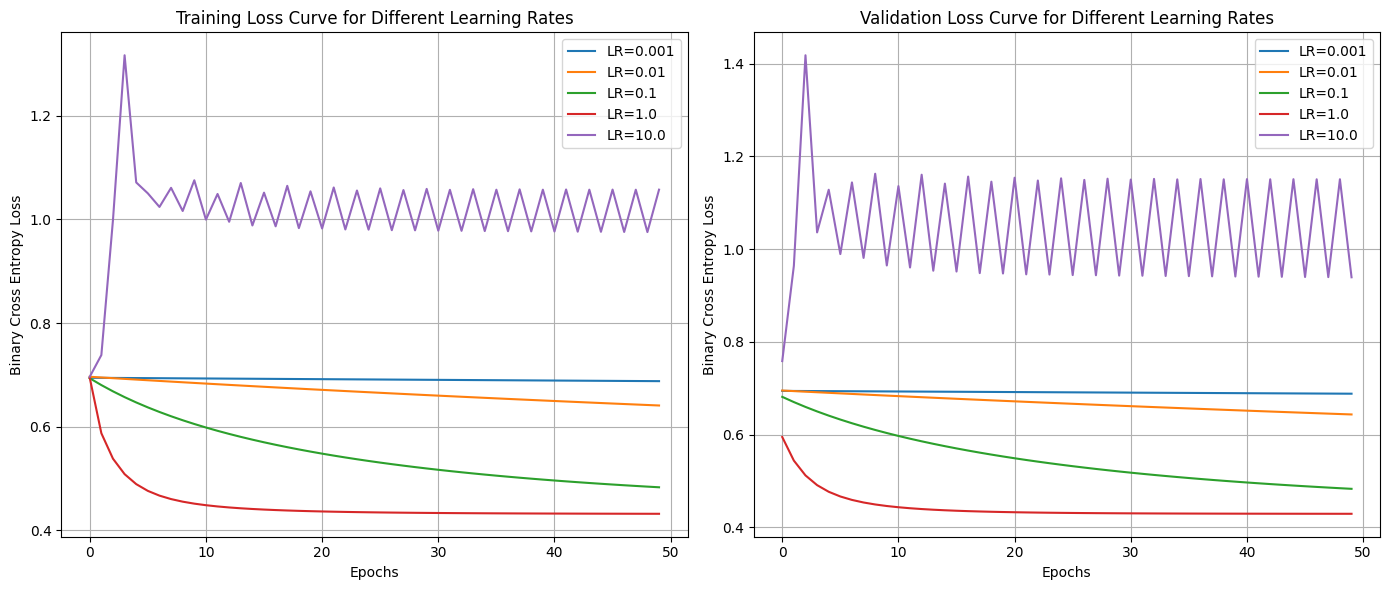

In [100]:
np.random.seed(42)

learning_rates = [0.001, 0.01, 0.1, 1.0, 10.0]
train_losses = {}
val_losses = {}
models_lr = {}

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

for lr in learning_rates:
    # TODO: Initialize and train LogisticRegressionBinary model for 50 epochs.
    model = LogisticRegressionBinary(learning_rate=lr, epochs=50)
    model.fit(X_train_aug, y_train_bin, X_val_aug, y_val_bin)

    train_losses[lr] = model.train_loss_history
    val_losses[lr] = model.val_loss_history
    models_lr[lr] = model

    # Subplot for train losses
    plt.plot(model.train_loss_history, label=f'LR={lr}')

plt.title('Training Loss Curve for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)

# Subplot for validation losses
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(val_losses[lr], label=f'LR={lr}')

plt.title('Validation Loss Curve for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Q3**: How does the choice of learning rate affect convergence behavior? Discuss the borderline cases of very small and very large learning rates.
  
**Answer**: Very small learning rates does very small changes so it will take very long time and need very much epoch; therefore, they are not efficient for training. Very large learning rates does very big changes so they may not find the optimal points if they are between the points it changes in 1 epoch.

Now, predict labels using the model trained with learning_rate = 0.1  for the test split and (using scikit-learn) compute and print classification metrics: accuracy, precision, recall, F1.

In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = models_lr[0.1]

# TODO: First, get the model predictions on the test set, then evaluate the predictions using the imported functions.
y_pred = model.predict(X_test_aug)

print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("Precision:", precision_score(y_test_bin, y_pred))
print("Recall:", recall_score(y_test_bin, y_pred))
print("F1-score:", f1_score(y_test_bin, y_pred))


Accuracy: 0.8228105906313645
Precision: 0.6
Recall: 0.28125
F1-score: 0.3829787234042553


**Q4**: You should observe that the accuracy is sufficiently high but the other metrics are not. What may be the reason behind this difference? Why/when can accuracy be misleading and how do the other metrics help?

**Answer:** The imbalanced data (3838, 1060) would cause that because accuracy can be misleading when tha data imbalanced.

Precision helps us to understand whether our model ensure with its predictions or not.

Recall gives us the information about missing actual positives. If the model miss too much positive sample, it will be very low.

F1-score is the harmonic mean of the precision and recall and help us the evaluate both together with different thresholds.

**Bonus**: As you observed, standard logistic regression may be biased toward the majority class with imbalanced datasets. One possible solution is to weight the loss and corresponding gradients so that errors on the minority class are penalized more heavily. Now, implement a class WeightedLogisticRegressionBinary that follows the same structure as LogisticRegressionBinary, but modifies the loss and gradient computations as follows:

* Assign a weight  $w_{\text{minor}} = \frac{\text{number of majority-class samples}}{\text{number of minority-class samples}}$ to samples belonging to the minority class.
* Assign a weight of 1 to samples belonging to the majority class.

Use these weights when computing both the binary cross-entropy loss and its gradients.

Then:
* Train the weighted model for 50 epochs using a learning rate of 0.1.

* Evaluate the trained model on the test set using accuracy, precision, recall, and F1-score.

* Compare the results with the unweighted logistic regression model.
You should observe an increase in F1-score, reflecting improved performance on the minority class.

In [102]:
class WeightedLogisticRegressionBinary:
    #TODO
    # I started with copying the LogisticRegressionBinary Class, then edit it for new case.
    def __init__(self, learning_rate=0.01, epochs=100, threshold=0.5):
        self.lr = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.weights = None
        self.train_loss_history = []
        self.val_loss_history = []

        self.w_minor = None
        self.minority = None

    def sigmoid(self, logits):
        # Clip logits to avoid overflow/underflow
        logits = np.clip(logits, -250, 250)

        # TODO: Implement sigmoid function
        return 1/(1+np.exp(-logits))

    def get_probs(self, X):
        # TODO: Implement this function that will perform the forward pass (linear model + sigmoid) and return the probabilities assigned.
        return self.sigmoid(np.dot(X, self.weights))

    def compute_loss(self, y_true, y_pred):
        # Add small constant to avoid log(0)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

        # TODO: Implement the binary cross-entropy loss
        loss = -np.mean((self.w_minor if self.minority == 1 else 1) * y_true * np.log(y_pred) + (self.w_minor if self.minority == 0 else 1) * (1 - y_true) * np.log(1 - y_pred))
        return loss

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        n, f = X_train.shape
        # Weight Initialization with random small weights
        self.weights = np.random.rand(f) * 0.01

        self.minority = np.sum(y_train == 1)<np.sum(y_train == 0)
        self.w_minor = np.sum(y_train == 1-self.minority) / np.sum(y_train == self.minority)
        sample_weights = np.where(y_train == 1, self.w_minor, 1.0)

        for i in range(self.epochs):
            # TODO: Forward pass (linear model + sigmoid)
            y_pred = self.get_probs(X_train)

            # TODO: Compute loss (call self.compute_loss that you implemented)
            loss_train = self.compute_loss(y_train, y_pred)
            self.train_loss_history.append(loss_train)

            # TODO: Backward pass (gradient descent)
            # Calculate the gradient and perform the parameter update
            gradient = np.dot(X_train.T, np.where(y_train==self.minority, self.w_minor, 1) * (y_pred - y_train)) / n
            self.weights -= self.lr * gradient

            # Validation
            if X_val is not None and y_val is not None:
              # TODO: Forward pass (linear model + sigmoid)
              y_pred_val = self.get_probs(X_val)

              # TODO: Compute loss (call self.compute_loss that you implemented)
              loss_val = self.compute_loss(y_val, y_pred_val)
              self.val_loss_history.append(loss_val)

              # No gradient descent here since this is the validation set.

    def predict(self, X):
        # TODO: Implement this function which will output the model prediction (1 or 0) on X
        return self.sigmoid(np.dot(X, self.weights)) >= self.threshold

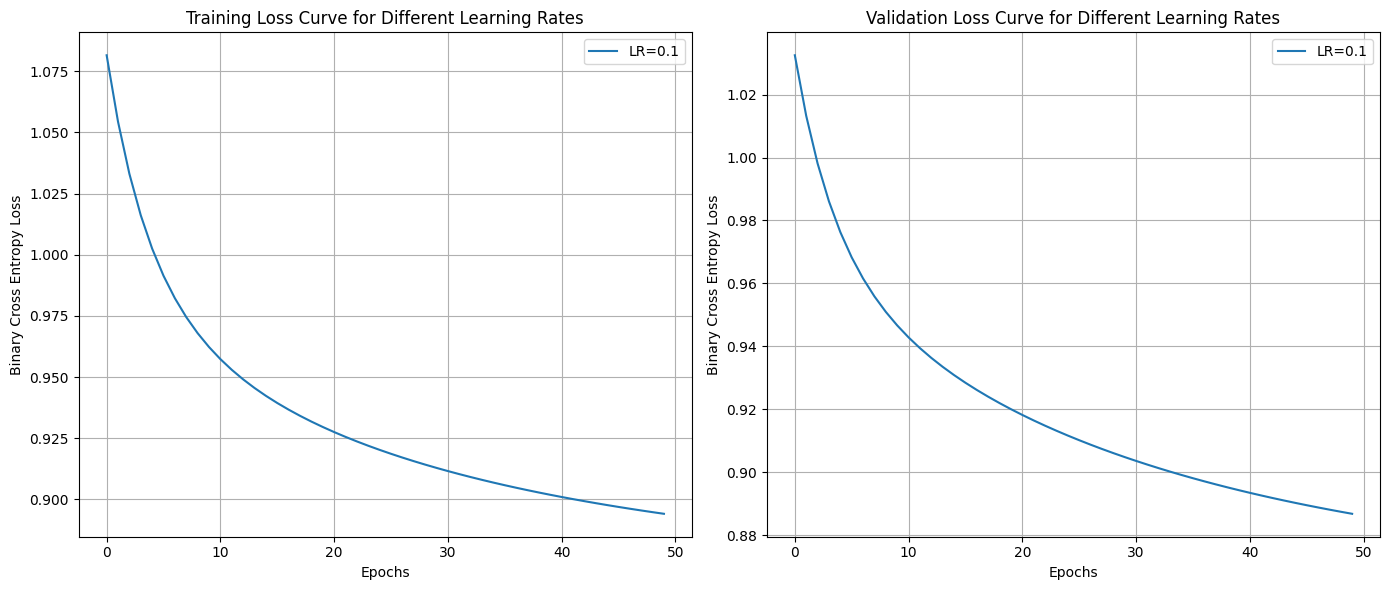

In [103]:
np.random.seed(42)

lr = 0.1

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

# TODO: Initialize and train LogisticRegressionBinary model for 50 epochs.
model = WeightedLogisticRegressionBinary(learning_rate=lr, epochs=50)
model.fit(X_train_aug, y_train_bin, X_val_aug, y_val_bin)

# Subplot for train losses
plt.plot(model.train_loss_history, label=f'LR={lr}')

plt.title('Training Loss Curve for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)

# Subplot for validation losses
plt.subplot(1, 2, 2)
plt.plot(model.val_loss_history, label=f'LR={lr}')

plt.title('Validation Loss Curve for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [104]:
# TODO: First, get the model predictions on the test set, then evaluate the predictions using the imported functions.
y_pred = model.predict(X_test_aug)

print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("Precision:", precision_score(y_test_bin, y_pred))
print("Recall:", recall_score(y_test_bin, y_pred))
print("F1-score:", f1_score(y_test_bin, y_pred))


Accuracy: 0.7311608961303462
Precision: 0.40425531914893614
Recall: 0.7916666666666666
F1-score: 0.5352112676056338


| Metrics | Weighted | Unweighted |
|---|---|---|
|Accuracy |0.73116|0.82281|
|Precision|0.40426|0.6|
|Recall   |0.79167|0.28125|
|F1       |0.53521|0.38298|


# 3. Multiclass Classification

Now, we will return to the original settings and try to predict a class from more than 2 options for a given datapoint. In other words, we will perform multiclass classification.  

Remember that the dataset originally has 7 different labels (3, 4, 5, 6, 7, 8, 9) and we mapped these labels to class indices (0, 1, 2, 3, 4, 5, 6). In this part, you will implement three different approaches to train a multiclass classifier:


*   One-vs-Rest (OvR)
*   One-vs-One (OvO)
*   Softmax

**3.1 One-vs-Rest (OvR)**

In [105]:
np.random.seed(42)

class LogisticRegressionOvR:
    def __init__(self, learning_rate=0.1, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.models = []
        self.classes = []

    def fit(self, X, y):
        # TODO: Extract unique classes from the data labels.
        # Then, train a binary classifier (use LogisticRegressionBinary that you implemented)
        # for each class and store each in self.models.
        self.classes = np.unique(y)
        for c in self.classes:
            model = LogisticRegressionBinary(learning_rate=self.lr, epochs=self.epochs)
            model.fit(X, (y == c))
            self.models.append(model)


    def predict(self, X):
        # TODO: Gather probabilities from all models and return the class with highest probability
        probs = np.array([model.get_probs(X) for model in self.models])
        return self.classes[np.argmax(probs, axis=0)]

# Train OvR and evaluate on the test split
ovr_model = LogisticRegressionOvR(learning_rate=0.1, epochs=50)
ovr_model.fit(X_train_aug, y_train)
y_pred_ovr = ovr_model.predict(X_test_aug)

print("OvR Accuracy:", accuracy_score(y_test, y_pred_ovr))

OvR Accuracy: 0.5437881873727087


**Q5**: Consider a multiclass classification problem with $K$ classes, trained using the One-vs-Rest (OvR) logistic regression approach on a dataset containing $N$ samples, each with $f$ features. Answer the following questions in terms of $N$, $f$ and $K$:

a) How many classifiers are trained?

b) What is the total number of parameters?

c) How many training samples are used to train each classifier?

**Answer:**

a) $K$

b) $K \times (f+1)$

c) $N$

**3.2 One-vs-One (OvO)**

In [106]:
np.random.seed(42)

class LogisticRegressionOvO:
    def __init__(self, learning_rate=0.1, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.models = []
        self.classes = []

    def fit(self, X, y):
        # TODO: Extract unique classes from the data labels.
        # Then, train a binary classifier (use LogisticRegressionBinary that you implemented)
        # for each pair of classes and store each in self.models.
        self.classes = np.unique(y)
        for i in range(len(self.classes)):
            for j in range(i+1, len(self.classes)):
                model = LogisticRegressionBinary(learning_rate=self.lr, epochs=self.epochs)
                idx = np.where(np.logical_or(y == self.classes[i], y == self.classes[j]))[0]
                X_sub = X[idx]
                y_sub = (y[idx] == self.classes[i])
                model.fit(X_sub, y_sub)
                self.models.append(model)

    def predict(self, X):
        # TODO: Check predictions from each model and use majority voting for the final predictions.
        # Hint: Each binary classifier votes for one of the two labels it was trained on. Final prediction is the class with the highest vote.
        votes = np.zeros((len(self.classes), X.shape[0]))
        n = 0
        for i in range(len(self.classes)):
            for j in range(i+1, len(self.classes)):
                model = self.models[n]
                votes[i] += model.predict(X)
                votes[j] += 1 - model.predict(X)
                n+=1
        return self.classes[np.argmax(votes, axis=0)]

# Train OvO and evaluate on the test split
ovo_model = LogisticRegressionOvO(learning_rate=0.1, epochs=50)
ovo_model.fit(X_train_aug, y_train)
y_pred_ovo = ovo_model.predict(X_test_aug)

print("OvO Accuracy:", accuracy_score(y_test, y_pred_ovo))

OvO Accuracy: 0.5437881873727087


**Q6**: Consider a multiclass classification problem with $K$ classes, trained using the One-vs-One (OvO) logistic regression approach on a dataset containing $N$ samples, each with $f$ features. Answer the following questions in terms of $N$, $f$ and $K$:

a) How many classifiers are trained?

b) What is the total number of parameters?

c) Assuming that the dataset contains an equal number of samples from each class, how many training samples are used to train each classifier?

**Answer:**

a) $\frac{K(K+1)}{2}$

b) $\frac{K(K+1)}{2} \times (f+1)$

c) $\frac{2N}{K}$

**3.3 Softmax**

Softmax Accuracy: 0.5437881873727087


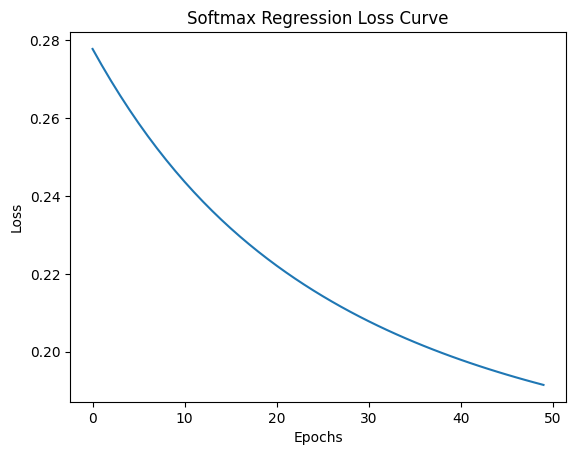

In [107]:
np.random.seed(42)

class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, epochs=50, n_classes=3):
        self.lr = learning_rate
        self.epochs = epochs
        self.n_classes = n_classes
        self.weights = None
        self.loss_history = []
        self.classes = []

    def softmax(self, logits):
        # Subtract max for numerical stability (prevents exp overflow)
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    # This function returns the one-hot encodings of the labels in the data.
    def one_hot_encode(self, y):
        one_hot = np.zeros((len(y), self.n_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot

    def fit(self, X, y):
        self.classes = np.unique(y)
        n, f = X.shape

        # Weight Initialization with random small weights
        self.weights = np.random.rand(f, self.n_classes) * 0.01

        y_one_hot = self.one_hot_encode(y)

        for i in range(self.epochs):
            # TODO: Forward pass (linear model + softmax)
            logits = np.dot(X, self.weights)
            y_pred = self.softmax(logits)

            # TODO: Compute loss.
            loss = -np.mean(y_one_hot * np.log(y_pred))
            self.loss_history.append(loss)

            # TODO: Backward pass (gradient descent)
            # Calculate the gradient and update the parameters
            gradient = np.dot(X.T, y_pred - y_one_hot) / n
            self.weights -= self.lr * gradient


    def predict(self, X):
        # TODO: Implement this function which will output the model prediction (the assigned classes) on X
        return np.argmax(np.dot(X, self.weights), axis=1)

# Train Softmax and evaluate on the test split
# Get the actual number of unique classes from the training data
n_classes_data = len(np.unique(y_train))
softmax_model = SoftmaxRegression(learning_rate=0.1, epochs=50, n_classes=n_classes_data)
softmax_model.fit(X_train_aug, y_train)
y_pred_soft = softmax_model.predict(X_test_aug)

print("Softmax Accuracy:", accuracy_score(y_test, y_pred_soft))

# Plot Softmax Loss
plt.plot(softmax_model.loss_history)
plt.title('Softmax Regression Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

**Q7**: Consider a multiclass classification problem with $K$ classes, trained using Softmax logistic regression on a dataset containing $N$ samples, each with $f$ features. Answer the following questions in terms of $N$, $f$ and $K$:

a) How many classifiers are trained?

b) What is the total number of parameters?

c) How many training samples are used to train each classifier?

**Answer:**

a) 1

b) $K \times (f+1)$

c) $N$